In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

torch.manual_seed(42)
np.random.seed(42)

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
    
print(device)

cuda


## Part 1: Building basic VAE

In [2]:
batch_size = 128

trans = transforms.ToTensor()

train_data = datasets.MNIST(root="./data", train=True, download=True, transform=trans)
test_data = datasets.MNIST(root="./data", train=False, download=True, transform=trans)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

print("Train size:", len(train_data))
print("Test size:", len(test_data))

for imgs, labels in train_loader:
    print(imgs.shape)
    break

100%|██████████| 9.91M/9.91M [00:00<00:00, 107MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 21.2MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 78.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.1MB/s]

Train size: 60000
Test size: 10000
torch.Size([128, 1, 28, 28])


In [3]:
class Encoder(nn.Module):
    def __init__(self, in_features=784, hidden_size=400, z_dim=20):
        super().__init__()
        self.layer1 = nn.Linear(in_features, hidden_size)
        self.mu_layer = nn.Linear(hidden_size, z_dim)
        self.logvar_layer = nn.Linear(hidden_size, z_dim)

    def forward(self, x):
        h = F.relu(self.layer1(x))
        mu = self.mu_layer(h)
        logvar = self.logvar_layer(h)
        return mu, logvar


class Decoder(nn.Module):
    def __init__(self, z_dim=20, hidden_size=400, out_features=784):
        super().__init__()
        self.layer1 = nn.Linear(z_dim, hidden_size)
        self.out_layer = nn.Linear(hidden_size, out_features)

    def forward(self, z):
        h = F.relu(self.layer1(z))
        out = torch.sigmoid(self.out_layer(h))
        return out

In [4]:
class VAE(nn.Module):
    def __init__(self, in_features=784, hidden_size=400, z_dim=20):
        super().__init__()
        self.encoder = Encoder(in_features, hidden_size, z_dim)
        self.decoder = Decoder(z_dim, hidden_size, in_features)
        self.z_dim = z_dim

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + std * eps
        return z

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        reconstructed = self.decoder(z)
        return reconstructed, mu, logvar

In [5]:
#loss function
def calc_loss(x_recon, x, mu, logvar):
    x = x.view(x.shape[0], -1)
    bce = F.binary_cross_entropy(x_recon, x, reduction="sum")
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    total = bce + kl
    return total, bce, kl

In [6]:
z_dim = 2
hidden_size = 400
lr = 0.001
epochs = 15

model = VAE(in_features=784, hidden_size=hidden_size, z_dim=z_dim)
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

print(model)

VAE(
  (encoder): Encoder(
    (layer1): Linear(in_features=784, out_features=400, bias=True)
    (mu_layer): Linear(in_features=400, out_features=2, bias=True)
    (logvar_layer): Linear(in_features=400, out_features=2, bias=True)
  )
  (decoder): Decoder(
    (layer1): Linear(in_features=2, out_features=400, bias=True)
    (out_layer): Linear(in_features=400, out_features=784, bias=True)
  )
)


In [7]:
#training
def train_one_epoch(model, dataloader, opt, device):
    model.train()
    total_loss = 0
    total_bce = 0
    total_kl = 0
    
    for images, labels in dataloader:
        images = images.to(device)
        images = images.view(images.shape[0], -1)

        opt.zero_grad()
        recon, mu, logvar = model(images)
        loss, bce, kl = calc_loss(recon, images, mu, logvar)
        loss.backward()
        opt.step()

        total_loss = total_loss + loss.item()
        total_bce = total_bce + bce.item()
        total_kl = total_kl + kl.item()

    num_items = len(dataloader.dataset)
    return total_loss / num_items, total_bce / num_items, total_kl / num_items

def evaluate_model(model, dataloader, device):
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            images = images.view(images.shape[0], -1)
            recon, mu, logvar = model(images)
            loss, bce, kl = calc_loss(recon, images, mu, logvar)
            total_loss = total_loss + loss.item()
            
    return total_loss / len(dataloader.dataset)

In [8]:
train_losses = []
train_bce_losses = []
train_kl_losses = []
test_losses = []

for e in range(epochs):
    tr_loss, tr_bce, tr_kl = train_one_epoch(model, train_loader, optimizer, device)
    te_loss = evaluate_model(model, test_loader, device)

    train_losses.append(tr_loss)
    train_bce_losses.append(tr_bce)
    train_kl_losses.append(tr_kl)
    test_losses.append(te_loss)

    print("Epoch", e + 1, "Train Loss:", round(tr_loss, 2), "Test Loss:", round(te_loss, 2))

Epoch 1 Train Loss: 190.4 Test Loss: 172.99
Epoch 2 Train Loss: 169.93 Test Loss: 166.94
Epoch 3 Train Loss: 165.25 Test Loss: 163.7
Epoch 4 Train Loss: 162.56 Test Loss: 161.25
Epoch 5 Train Loss: 160.67 Test Loss: 159.67
Epoch 6 Train Loss: 159.18 Test Loss: 158.66
Epoch 7 Train Loss: 158.0 Test Loss: 157.42
Epoch 8 Train Loss: 156.93 Test Loss: 156.52
Epoch 9 Train Loss: 155.98 Test Loss: 156.05
Epoch 10 Train Loss: 155.15 Test Loss: 155.48
Epoch 11 Train Loss: 154.48 Test Loss: 154.49
Epoch 12 Train Loss: 153.81 Test Loss: 154.2
Epoch 13 Train Loss: 153.24 Test Loss: 153.65
Epoch 14 Train Loss: 152.68 Test Loss: 153.43
Epoch 15 Train Loss: 152.29 Test Loss: 153.02


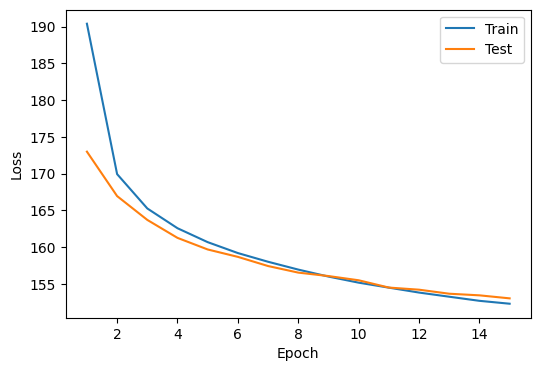

In [9]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, epochs + 1), train_losses, label="Train")
plt.plot(range(1, epochs + 1), test_losses, label="Test")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Part 2: Analyzing VAE performance

latent space visualization

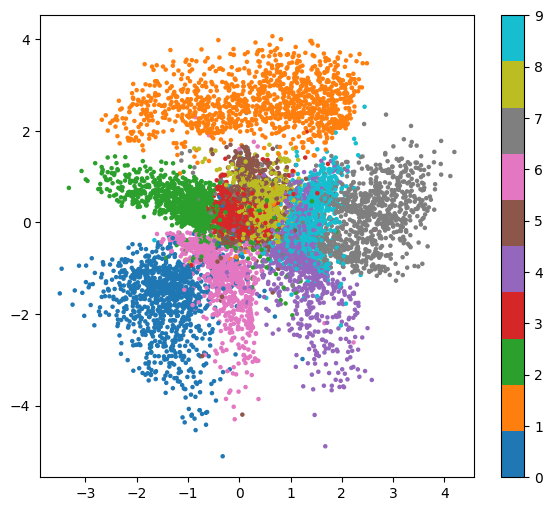

In [10]:
model.eval()

all_means = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device).view(images.shape[0], -1)
        mu, logvar = model.encoder(images)
        all_means.append(mu.cpu().numpy())
        all_labels.append(labels.numpy())

all_means = np.concatenate(all_means, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

if all_means.shape[1] == 2:
    plot_data = all_means
else:
    from sklearn.decomposition import PCA
    pca = PCA(n_components=2)
    plot_data = pca.fit_transform(all_means)

plt.figure(figsize=(7, 6))
plt.scatter(plot_data[:, 0], plot_data[:, 1], c=all_labels, cmap="tab10", s=5)
plt.colorbar()
plt.show()

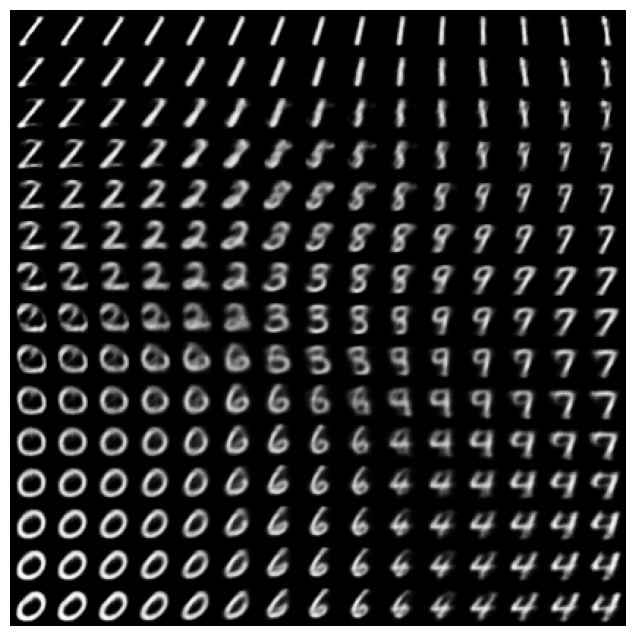

In [11]:
if z_dim == 2:
    grid_size = 15
    x_vals = np.linspace(-2.5, 2.5, grid_size)
    y_vals = np.linspace(-2.5, 2.5, grid_size)
    
    final_image = np.zeros((28 * grid_size, 28 * grid_size))

    with torch.no_grad():
        for i, y in enumerate(reversed(y_vals)):
            for j, x in enumerate(x_vals):
                z = torch.tensor([[x, y]], dtype=torch.float32).to(device)
                decoded = model.decoder(z).view(28, 28).cpu().numpy()
                final_image[i * 28 : (i + 1) * 28, j * 28 : (j + 1) * 28] = decoded

    plt.figure(figsize=(8, 8))
    plt.imshow(final_image, cmap="gray")
    plt.axis("off")
    plt.show()

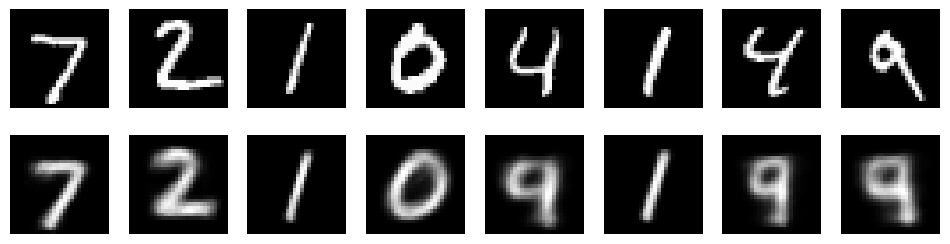

In [12]:
model.eval()

num_images = 8
test_iter = iter(test_loader)
batch_x, batch_y = next(test_iter)

subset_x = batch_x[:num_images].to(device)

with torch.no_grad():
    recon_x, mu, logvar = model(subset_x.view(num_images, -1))
    recon_x = recon_x.view(num_images, 1, 28, 28).cpu()

fig, ax = plt.subplots(2, num_images, figsize=(12, 3))

for i in range(num_images):
    ax[0, i].imshow(subset_x[i].cpu().squeeze(), cmap="gray")
    ax[0, i].axis("off")
    
    ax[1, i].imshow(recon_x[i].squeeze(), cmap="gray")
    ax[1, i].axis("off")

plt.show()

generating new samples

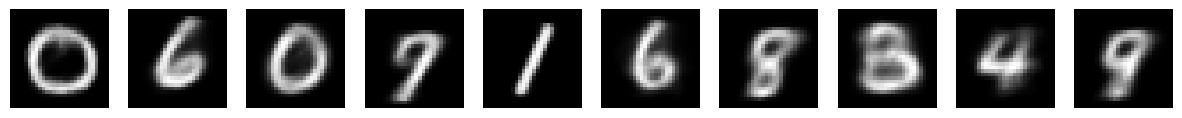

In [13]:
model.eval()

num_gen = 10
with torch.no_grad():
    random_z = torch.randn(num_gen, z_dim).to(device)
    new_imgs = model.decoder(random_z).view(num_gen, 28, 28).cpu()

fig, ax = plt.subplots(1, num_gen, figsize=(15, 2))
for i in range(num_gen):
    ax[i].imshow(new_imgs[i], cmap="gray")
    ax[i].axis("off")
    
plt.show()